# Holt-Winters Exponential Smoothing

**Navigation**: [← Previous: Simple Exponential Smoothing](02_ses.ipynb) | [Next: Fourier Analysis →](04_fourier.ipynb)

Holt's method adds trend; Holt-Winters adds seasonality. The ETS framework unifies error, trend, and seasonal components.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('projects/time-series-analysis/data')

def load_series(name):
    """Load a bundled CSV as a DatetimeIndex Series."""
    df = pd.read_csv(DATA_DIR / name, parse_dates=['date'])
    return df.set_index('date')['value'].sort_index()

def load_air_passengers():
    path = DATA_DIR / 'air_passengers.csv'
    if path.exists():
        return load_series('air_passengers.csv')
    from statsmodels.datasets import get_rdataset
    air = get_rdataset('AirPassengers', 'datasets').data
    s = air['value']
    s.index = pd.date_range('1949-01', periods=len(s), freq='MS')
    return s

def load_milk():
    path = DATA_DIR / 'monthly_milk.csv'
    if path.exists():
        return load_series('monthly_milk.csv')
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-milk-production-pounds.csv'
    return pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

def load_co2():
    from statsmodels.datasets import co2
    return co2.load().data.resample('MS').mean().ffill().squeeze()

def load_sunspots():
    from statsmodels.datasets import sunspots
    d = sunspots.load_pandas().data
    return d.set_index('YEAR')['SUNACTIVITY']

def load_retail():
    path = DATA_DIR / 'uk_retail_sales.csv'
    if path.exists():
        return load_series('uk_retail_sales.csv')
    raise FileNotFoundError('uk_retail_sales.csv not found in data/')
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## Holt-Winters Recurrences

Level: $\ell_t = \alpha(y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1} + b_{t-1})$

Trend: $b_t = \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*)b_{t-1}$

Seasonal: $s_t = \gamma(y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)s_{t-m}$

Forecast: $\hat{y}_{t+h|t} = \ell_t + hb_t + s_{t+h-m(k+1)}$

In [2]:

air = load_air_passengers()
milk = load_milk()

# Multiplicative HW for Air Passengers
hw_mul = ExponentialSmoothing(
    air, trend='add', seasonal='mul', seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)
print(f'Air Passengers HW (mul): AIC={hw_mul.aic:.1f}')

# Additive HW for Milk
hw_add = ExponentialSmoothing(
    milk, trend='add', seasonal='add', seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)
print(f'Milk HW (add): AIC={hw_add.aic:.1f}')


Air Passengers HW (mul): AIC=709.9
Milk HW (add): AIC=557.3


/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [3]:

# ETS model selection via AIC
configs = [
    ('SES', dict()),
    ('Holt', dict(trend='add')),
    ('HW add', dict(trend='add', seasonal='add', seasonal_periods=12)),
    ('HW mul', dict(trend='add', seasonal='mul', seasonal_periods=12)),
]
rows = []
for label, kw in configs:
    m = ExponentialSmoothing(air, initialization_method='estimated', **kw).fit(optimized=True)
    rows.append({'Model': label, 'AIC': m.aic, 'BIC': m.bic})
pd.DataFrame(rows).sort_values('AIC')


/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Model,AIC,BIC
3,HW mul,709.891719,757.408732
2,HW add,753.293509,800.810522
0,SES,1016.124823,1022.064450
1,Holt,1019.488876,1031.368129


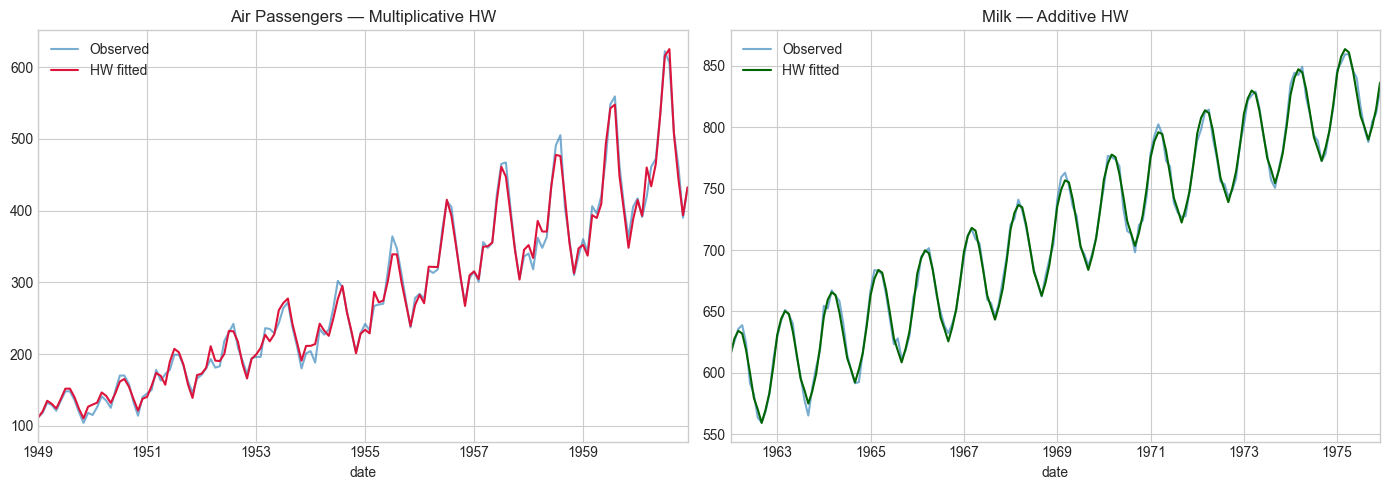

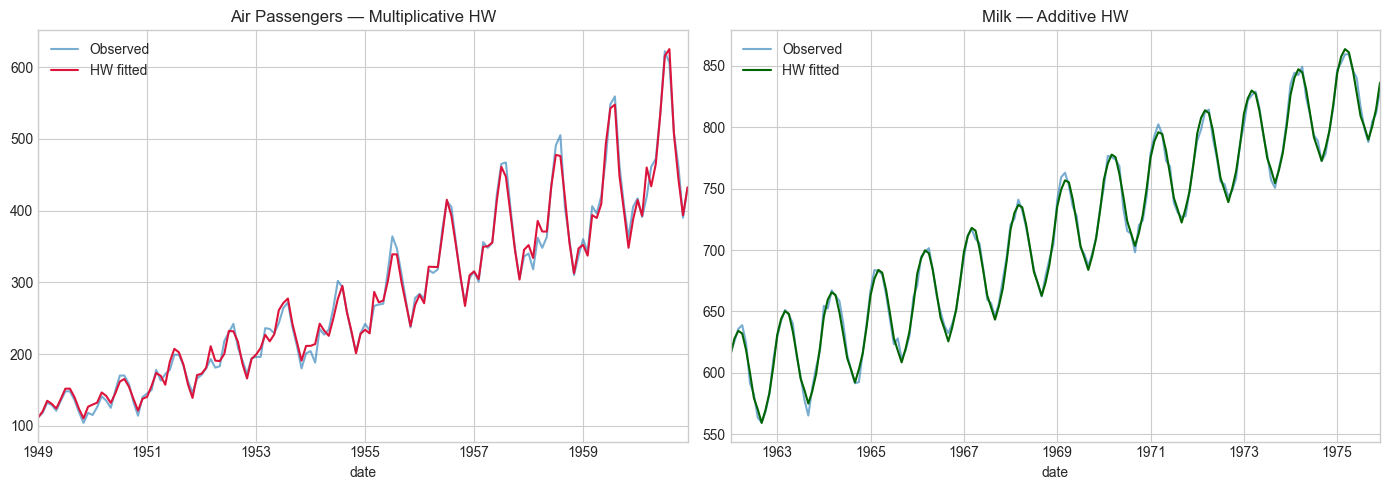

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
air.plot(ax=axes[0], label='Observed', alpha=0.6)
hw_mul.fittedvalues.plot(ax=axes[0], label='HW fitted', color='crimson')
axes[0].set_title('Air Passengers — Multiplicative HW')

milk.plot(ax=axes[1], label='Observed', alpha=0.6)
hw_add.fittedvalues.plot(ax=axes[1], label='HW fitted', color='darkgreen')
axes[1].set_title('Milk — Additive HW')
for ax in axes:
    ax.legend()
fig.tight_layout()
fig


## Key Takeaways

- **Multiplicative vs additive**: Use multiplicative when seasonal amplitude scales with level (Air Passengers).
- **ETS framework**: All HW variants are special cases of Error-Trend-Seasonal state-space models.
- **Damped trend**: Undamped linear trends produce unrealistic long-horizon forecasts — damped variants preferred in production.
- **AIC selection**: Compare ETS variants systematically rather than guessing seasonal form.

---

**Navigation**: [← Previous: Simple Exponential Smoothing](02_ses.ipynb) | [Next: Fourier Analysis →](04_fourier.ipynb)
